<a href="https://colab.research.google.com/github/GretelKMendez/Tareas-Mac-IA/blob/main/urgencias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problema: Clasificación Binaria.

Variable Objetivo (y): En este dataset, la columna enviado_a indica el destino del paciente. Según el diccionario de la DGIS, el valor "2" suele representar Hospitalización.

Variables Predictoras (X): edad, sexo, tipo_urgencia, mot_ate (motivo de atención) y horas_estancia.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Carga del dataset con la codificación adecuada
df = pd.read_csv('urgencias_2024_hjm.csv', encoding='latin-1')

# 2. Selección de variables relevantes según el archivo HJM
# 'mot_ate' es el motivo de atención, 'enviado_a' es nuestro destino
cols_modelo = ['edad', 'sexo', 'tipo_urgencia', 'mot_ate', 'horas_estancia', 'enviado_a']
df_filtered = df[cols_modelo].copy()

# 3. Limpieza: Manejo de valores nulos
# Eliminamos filas donde el destino sea desconocido para no sesgar el aprendizaje
df_filtered = df_filtered.dropna(subset=['enviado_a'])

# 4. Creación de la variable objetivo binaria
# Definimos 1 si es hospitalizado (valor 2) y 0 para cualquier otro destino
df_filtered['target'] = df_filtered['enviado_a'].apply(lambda x: 1 if x == 2 else 0)

# 5. Encoding de variables categóricas (Sexo y Motivo de Atención)
le = LabelEncoder()
df_filtered['sexo'] = le.fit_transform(df_filtered['sexo'].astype(str))
df_filtered['mot_ate'] = le.fit_transform(df_filtered['mot_ate'].astype(str))

# 6. Definición de X y y
X = df_filtered.drop(['enviado_a', 'target'], axis=1)
y = df_filtered['target']

# 7. División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(df)

             clues                institucion    folio  fecha_alta  edad  \
0      DFSSA003944  Hospital Juarez de Mexico        1  2024-01-01    17   
1      DFSSA003944  Hospital Juarez de Mexico        2  2024-01-01    22   
2      DFSSA003944  Hospital Juarez de Mexico        3  2024-01-01    20   
3      DFSSA003944  Hospital Juarez de Mexico        4  2024-01-01    20   
4      DFSSA003944  Hospital Juarez de Mexico        5  2024-01-01    28   
...            ...                        ...      ...         ...   ...   
62524  DFSSA003944  Hospital Juarez de Mexico  1043733  2024-12-31    82   
62525  DFSSA003944  Hospital Juarez de Mexico  1043734  2024-12-31    44   
62526  DFSSA003944  Hospital Juarez de Mexico  1043735  2024-12-31    38   
62527  DFSSA003944  Hospital Juarez de Mexico  1043736  2024-12-31    40   
62528  DFSSA003944  Hospital Juarez de Mexico  1043737  2024-12-31    68   

       sexo  ent_residencia  mun_residencia  derhab  tipo_urgencia  ...  \
0         2 

Utilizamos Random Forest porque es ideal para manejar la mezcla de datos numéricos (edad, horas) y categóricos (sexo, motivo) del Hospital Juárez.

In [4]:
# 1. Inicialización del modelo
# Usamos class_weight='balanced' porque usualmente hay menos hospitalizados que altas
modelo_hjm = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)

# 2. Entrenamiento
modelo_hjm.fit(X_train, y_train)

# 3. Predicción
y_pred = modelo_hjm.predict(X_test)

# 4. Evaluación de resultados
print("### Evaluación del Modelo - Hospital Juárez de México ###")
print(classification_report(y_test, y_pred))

### Evaluación del Modelo - Hospital Juárez de México ###
              precision    recall  f1-score   support

           0       0.96      0.57      0.72     11100
           1       0.19      0.82      0.31      1406

    accuracy                           0.60     12506
   macro avg       0.58      0.69      0.52     12506
weighted avg       0.87      0.60      0.67     12506



Con el modelo se predice la necesidad de cama desde el registro inicial.	Menos tiempo del paciente en pasillos de urgencias.

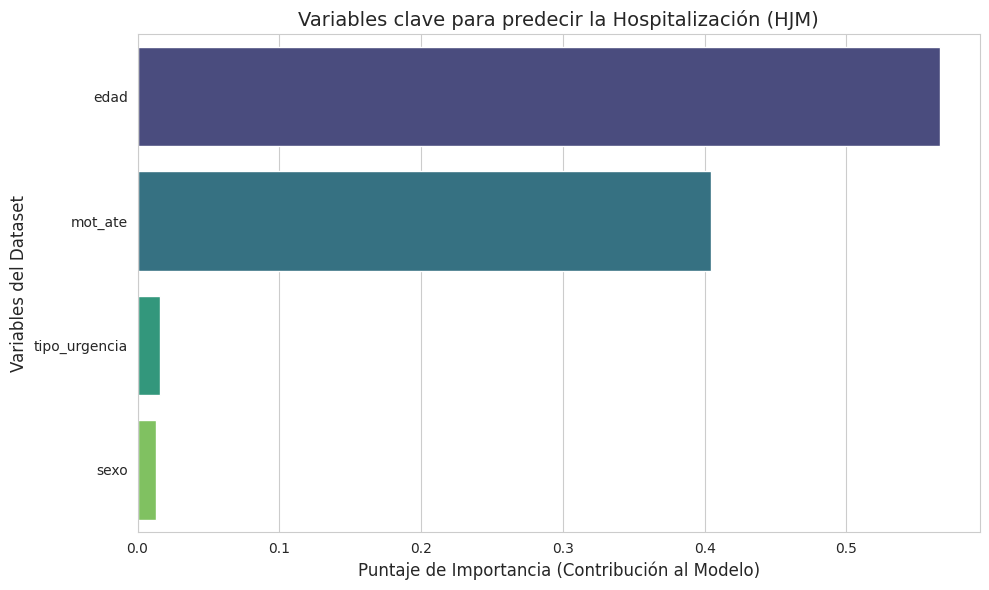

In [7]:
# Generación de la gráfica de importancia corregida
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Corrección: añadimos hue=importances.index y legend=False
sns.barplot(
    x=importances.values,
    y=importances.index,
    hue=importances.index,
    palette='viridis',
    legend=False
)

# Formato de la gráfica
plt.title('Variables clave para predecir la Hospitalización (HJM)', fontsize=14)
plt.xlabel('Puntaje de Importancia (Contribución al Modelo)', fontsize=12)
plt.ylabel('Variables del Dataset', fontsize=12)

plt.tight_layout()
plt.show()